<a href="https://colab.research.google.com/github/harshadbabar26-dev/HB1/blob/main/kuwait_policy_and_all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_excel("/content/finaldatset_with_policy.xlsx")

In [ ]:

df.tail(50)

,Country,Year,GDP,Inflation,Population,Migration,Migration_Flow,Oil_Price,Exchange_Rate,Unemployment,...,Omanisation_Policy,Labour_Law_Royal_Decree_35,Visa_Ban_Policy,Expansion_of_Omanisation,Labour_Law_Reform_2023,Bahrainization_Policy,Labour_Market_Reform_Law_2006,Labour_Law_No_36,Flexi_Permit,Labour_Registration_Program
61,Oman,2014,92.699,1.014015,4002000,785000,86000,98.97,2.6008,3.453,...,1,1,1,0,0,0,0,0,0,0
62,Oman,2015,78.711,0.065290,4185000,795000,84000,52.32,2.6008,3.403,...,1,1,1,0,0,0,0,0,0,0
63,Oman,2016,75.129,1.109208,4391000,780000,62000,43.64,2.6008,3.266,...,1,1,1,0,0,0,0,0,0,0
64,Oman,2017,80.857,1.589094,4537000,750000,53000,54.13,2.6008,2.523,...,1,1,1,0,0,0,0,0,0,0
65,Oman,2018,91.506,0.889312,4598000,715000,36000,71.34,2.6008,1.800,...,1,1,1,0,0,0,0,0,0,0
66,Oman,2019,88.061,0.490815,4591000,675000,28500,64.30,2.6008,2.045,...,1,1,1,0,0,0,0,0,0,0
67,Oman,2020,75.909,-0.406403,4522000,585000,8400,41.96,2.6008,2.940,...,1,1,1,0,0,0,0,0,0,0
68,Oman,2021,87.324,1.682212,4500000,520000,14200,70.86,2.6008,1.900,...,1,1,1,0,0,0,0,0,0,0
69,Oman,2022,109.853,2.506143,4730000,580000,46200,100.93,2.6008,3.300,...,1,1,1,0,0,0,0,0,0,0
70,Oman,2023,106.175,0.950783,5049000,630000,38500,82.49,2.6008,3.176,...,1,1,1,0,1,0,0,0,0,0


first kuwait policy analysis

Policy : Kuwaitization_Policy
Policy Year : 1998

DESCRIPTIVE ANALYSIS
----------------------------------------
count         3.000000
mean     236666.666667
std       25166.114784
min      210000.000000
25%      225000.000000
50%      240000.000000
75%      250000.000000
max      260000.000000
Name: Migration, dtype: float64

count    2.900000e+01
mean     7.048276e+05
std      2.637114e+05
min      2.800000e+05
25%      4.800000e+05
50%      7.000000e+05
75%      9.700000e+05
max      1.045000e+06
Name: Migration, dtype: float64

Mean Before : 236666.67
Mean After  : 704827.59
Difference  : 468160.92


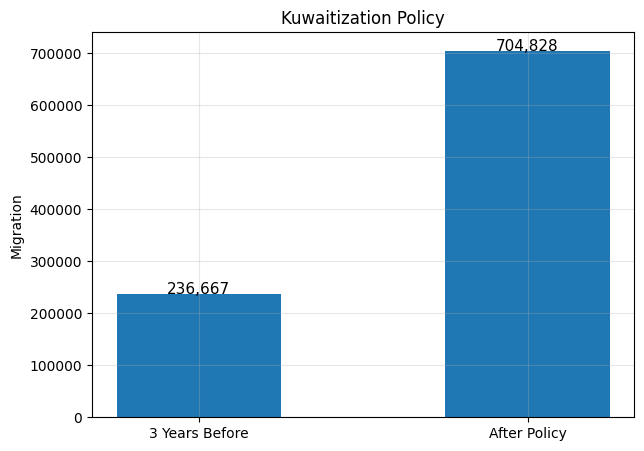


Variance Explained
[0.5729 0.2935 0.0862]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     918.7
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.35e-32
Time:                        02:49:23   Log-Likelihood:                -424.99
No. Observations:                  37   AIC:                             864.0
Df Residuals:                      30   BIC:                             875.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

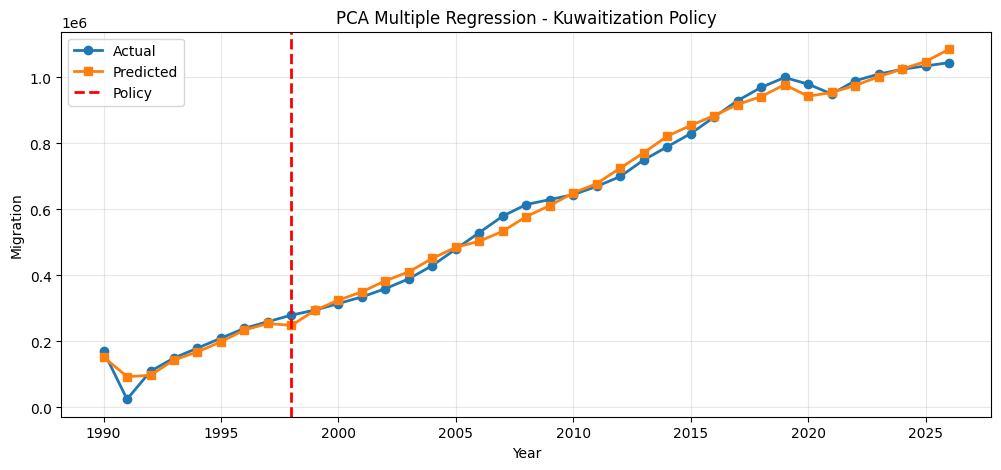

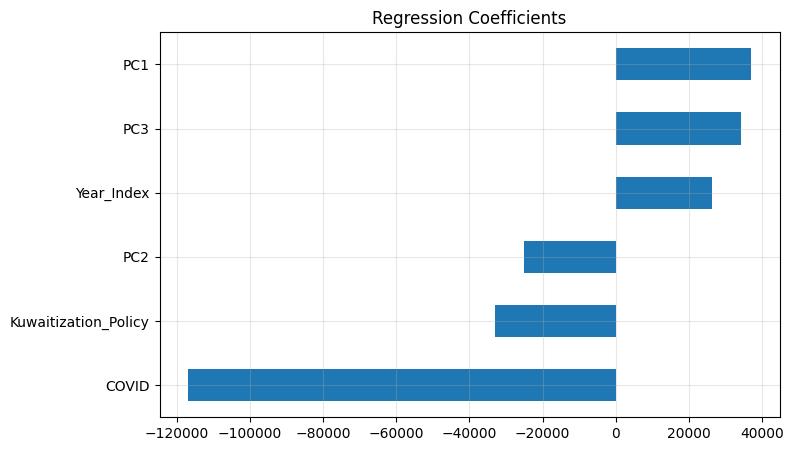

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

kuwait = df[df["Country"]=="Kuwait"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Kuwaitization_Policy"

policy_year = kuwait.loc[
    kuwait[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = kuwait[
    (kuwait["Year"] >= policy_year-3) &
    (kuwait["Year"] < policy_year)
]

after = kuwait[
    kuwait["Year"] >= policy_year
]

print("\nDESCRIPTIVE ANALYSIS")
print("-"*40)

print(before["Migration"].describe())
print()
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["3 Years Before","After Policy"],
    [before_mean,after_mean],
    width=.5
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Kuwaitization Policy")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

kuwait["COVID"]=(kuwait["Year"]>=2020).astype(int)

kuwait["Year_Index"]=(
    kuwait["Year"]-
    kuwait["Year"].min()
)

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=kuwait[economic_variables]

X=X.fillna(X.median())

y=kuwait["Migration"]

# Standardize

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

# PCA

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(
    np.round(
        pca.explained_variance_ratio_,
        4
    )
)

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=kuwait.index
)

reg_data=pd.concat([

    pca_df,

    kuwait[[

        "Migration",
        "COVID",
        "Year_Index",
        policy

    ]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(

    formula,

    data=reg_data

).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\nPerformance")

print("----------------------")

print(

"R² :",

round(

r2_score(

reg_data["Migration"],
reg_data["Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

reg_data["Migration"],
reg_data["Prediction"]

)

),2)

)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

kuwait["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

kuwait["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("PCA Multiple Regression - Kuwaitization Policy")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.legend()

plt.grid(alpha=.3)

plt.show()

# ======================================================
# COEFFICIENT PLOT
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()

ENHANCED INTERRUPTED TIME SERIES
Policy : Kuwaitization_Policy
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     46.80
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           8.44e-14
Time:                        02:49:35   Log-Likelihood:                -419.08
No. Observations:                  37   AIC:                             860.2
Df Residuals:                      26   BIC:                             877.9
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


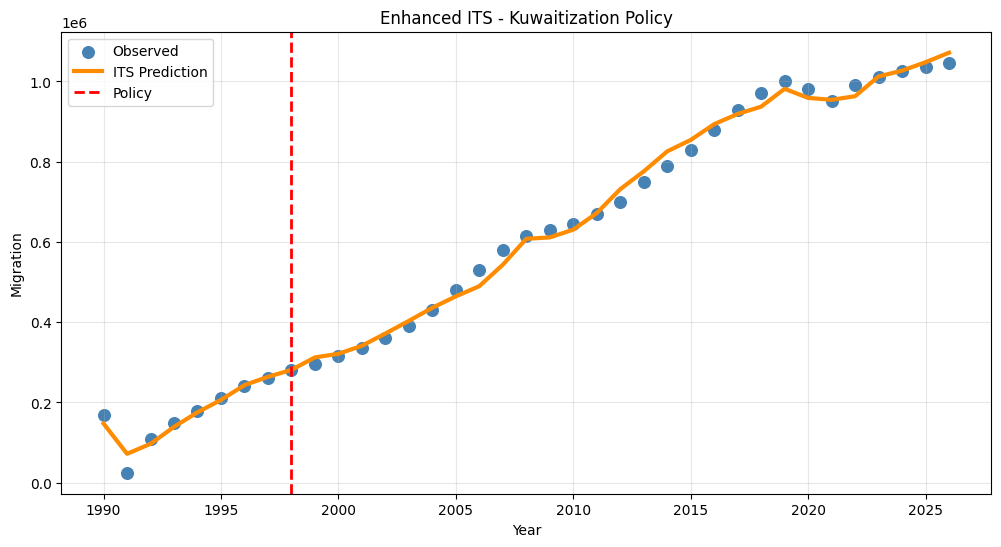

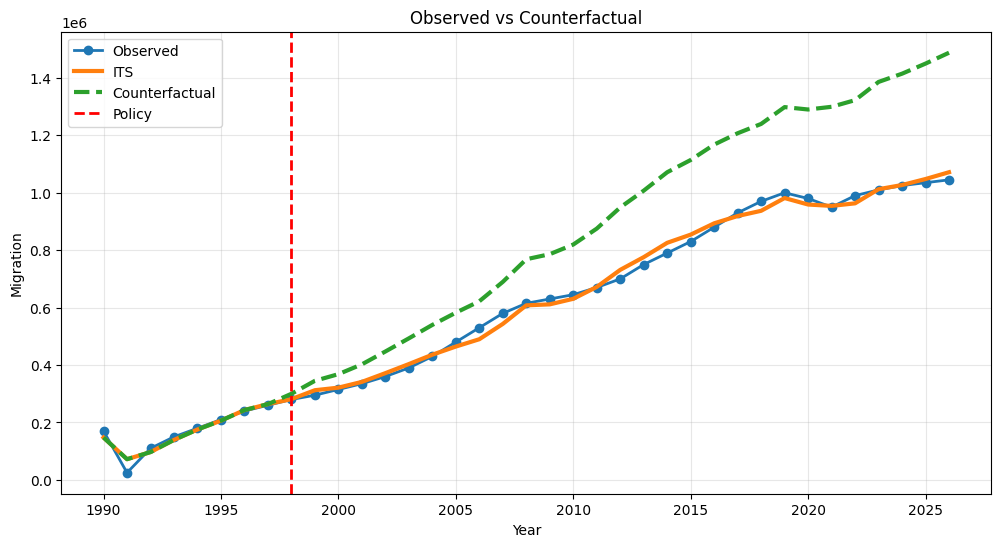

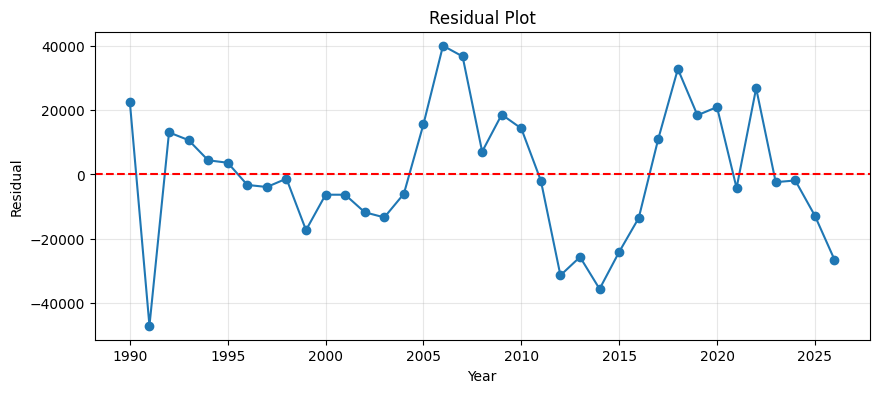

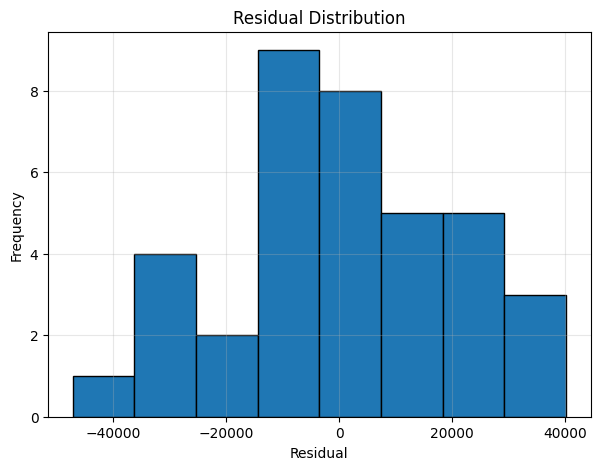


Durbin Watson : 1.122

INTERPRETATION
✗ Immediate level change is NOT statistically significant.
✓ Significant long-term trend change after policy.

Estimated Immediate Effect : -18555.33
Estimated Annual Trend Change : -7099.48


In [ ]:
# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# KUWAITIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------
# Sort Data
# ------------------------------------------------------

kuwait = kuwait.sort_values("Year").copy()

# ------------------------------------------------------
# Time Variables
# ------------------------------------------------------

kuwait["Time"] = kuwait["Year"] - policy_year

# Policy Indicator

kuwait["Policy"] = (
    kuwait["Year"] >= policy_year
).astype(int)

# Time After Policy

kuwait["Time_After"] = (
    kuwait["Time"].clip(lower=0)
)

# Interaction

kuwait["Policy_Time"] = (
    kuwait["Policy"] *
    kuwait["Time_After"]
)

# COVID Variable

kuwait["COVID"] = (
    kuwait["Year"] >= 2020
).astype(int)

# ------------------------------------------------------
# Enhanced ITS Model
# ------------------------------------------------------

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=kuwait

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ------------------------------------------------------
# Prediction
# ------------------------------------------------------

kuwait["ITS_Prediction"] = its.predict(kuwait)

# ------------------------------------------------------
# Performance
# ------------------------------------------------------

print("\nITS PERFORMANCE")
print("-"*40)

print(

"R² :",

round(

r2_score(

kuwait["Migration"],
kuwait["ITS_Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

kuwait["Migration"],
kuwait["ITS_Prediction"]

)

),2)

)

# ------------------------------------------------------
# Policy Effect
# ------------------------------------------------------

print("\nPolicy Coefficients")
print("-"*40)

print("Level Change      :", round(its.params["Policy"],2))
print("Slope Change      :", round(its.params["Policy_Time"],2))
print("Time Effect       :", round(its.params["Time"],2))

print("\nP-values")
print("-"*40)

print("Policy      :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ------------------------------------------------------
# Observed vs ITS Prediction
# ------------------------------------------------------

plt.figure(figsize=(12,6))

plt.scatter(

kuwait["Year"],
kuwait["Migration"],

color="steelblue",

s=70,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

color="darkorange",

linewidth=3,

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Enhanced ITS - Kuwaitization Policy")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Counterfactual Prediction
# ------------------------------------------------------

counter = kuwait.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

kuwait["Year"],
kuwait["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

linewidth=3,

label="ITS"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Residual Plot
# ------------------------------------------------------

kuwait["Residuals"] = (

kuwait["Migration"] -

kuwait["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

kuwait["Year"],

kuwait["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Residual Histogram
# ------------------------------------------------------

plt.figure(figsize=(7,5))

plt.hist(

kuwait["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Durbin Watson
# ------------------------------------------------------

dw = durbin_watson(its.resid)

print("\nDurbin Watson :", round(dw,3))

# ------------------------------------------------------
# Interpretation
# ------------------------------------------------------

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Significant immediate level change after Kuwaitization Policy.")
else:
    print("✗ Immediate level change is NOT statistically significant.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ Significant long-term trend change after policy.")
else:
    print("✗ Long-term trend change is NOT statistically significant.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

In [ ]:
df.columns

Index(['Country', 'Year', 'GDP', 'Inflation', 'Population', 'Migration',
       'Migration_Flow', 'Oil_Price', 'Exchange_Rate', 'Unemployment',
       'Kafala_Sponsorship_System', 'Kuwaitization_Policy',
       'Domestic_Workers_Law_No_68', 'Residency_Law_Reforms',
       'Labour_Market_Reform', 'Privat_Sector_Labor_Law',
       'Foreigners_Residency_Law_No_114', 'Omanisation_Policy',
       'Labour_Law_Royal_Decree_35', 'Visa_Ban_Policy',
       'Expansion_of_Omanisation', 'Labour_Law_Reform_2023',
       'Bahrainization_Policy', 'Labour_Market_Reform_Law_2006',
       'Labour_Law_No_36', 'Flexi_Permit', 'Labour_Registration_Program'],
      dtype='object')

kuwait second policy

Policy : Domestic_Workers_Law_No_68
Policy Year : 2015

DESCRIPTIVE ANALYSIS
----------------------------------------
count         3.000000
mean     746666.666667
std       45092.497528
min      700000.000000
25%      725000.000000
50%      750000.000000
75%      770000.000000
max      790000.000000
Name: Migration, dtype: float64

count    1.200000e+01
mean     9.704167e+05
std      6.436608e+04
min      8.300000e+05
25%      9.450000e+05
50%      9.850000e+05
75%      1.013750e+06
max      1.045000e+06
Name: Migration, dtype: float64

Mean Before : 746666.67
Mean After  : 970416.67
Difference  : 223750.0


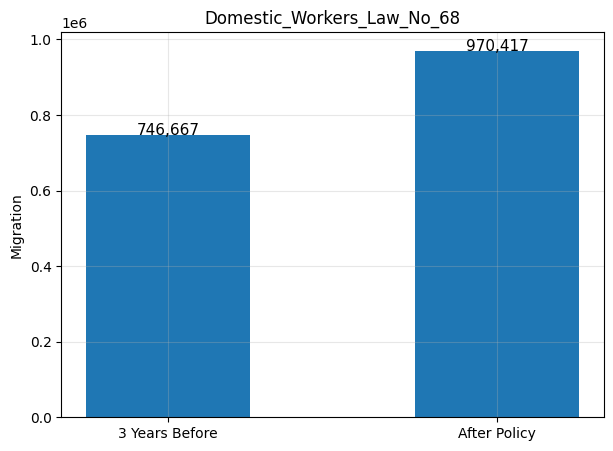


Variance Explained
[0.5729 0.2935 0.0862]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     1010.
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           3.29e-33
Time:                        02:50:06   Log-Likelihood:                -423.24
No. Observations:                  37   AIC:                             860.5
Df Residuals:                      30   BIC:                             871.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

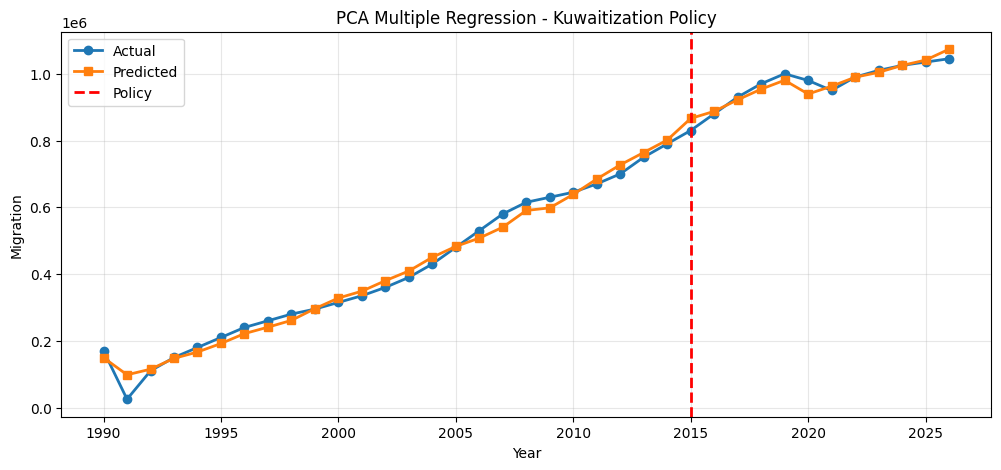

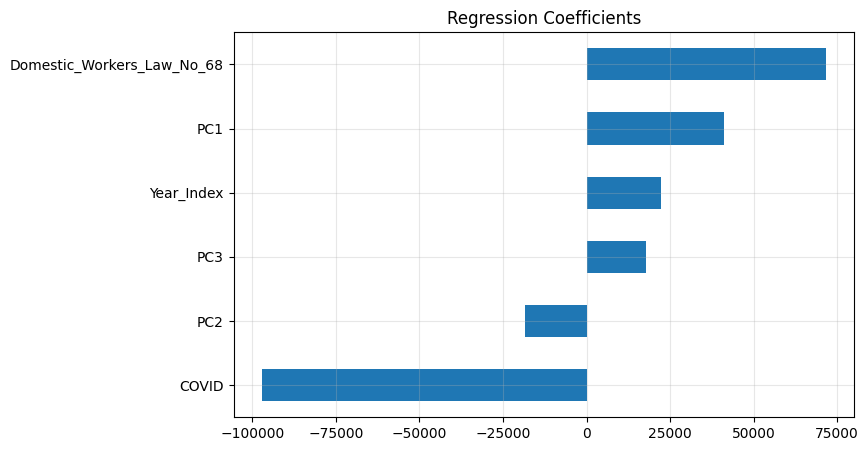

ENHANCED INTERRUPTED TIME SERIES
Policy : Domestic_Workers_Law_No_68
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     37.97
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.03e-12
Time:                        02:50:07   Log-Likelihood:                -420.87
No. Observations:                  37   AIC:                             863.7
Df Residuals:                      26   BIC:                             881.5
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


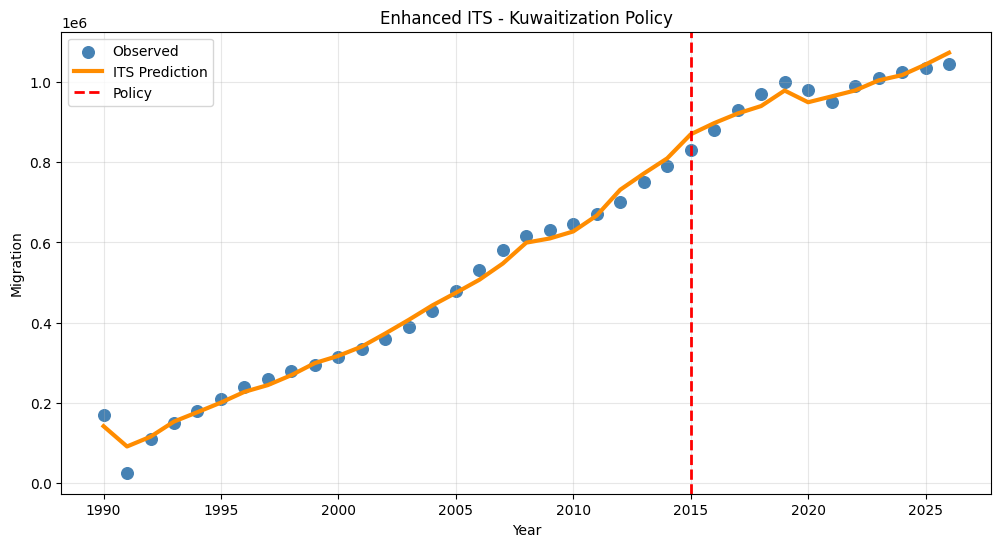

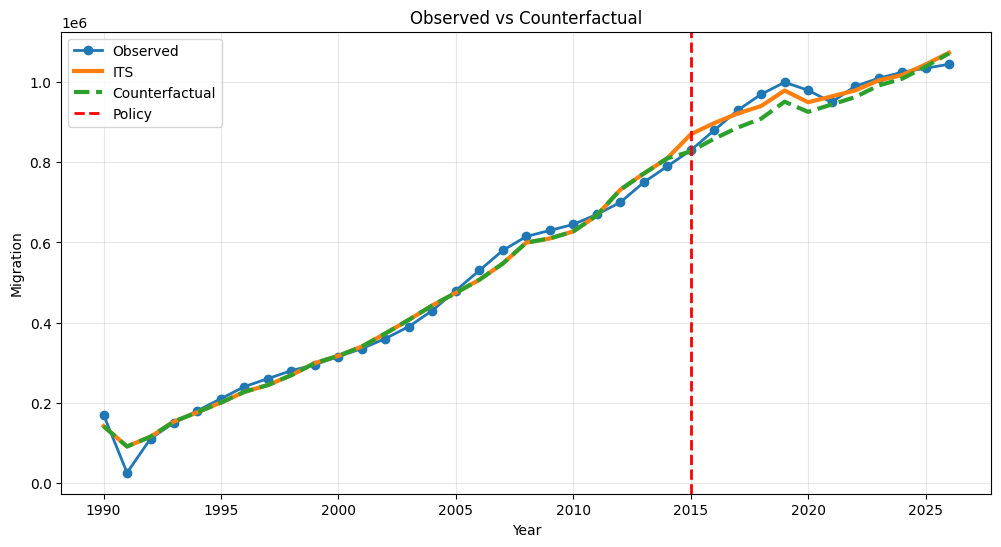

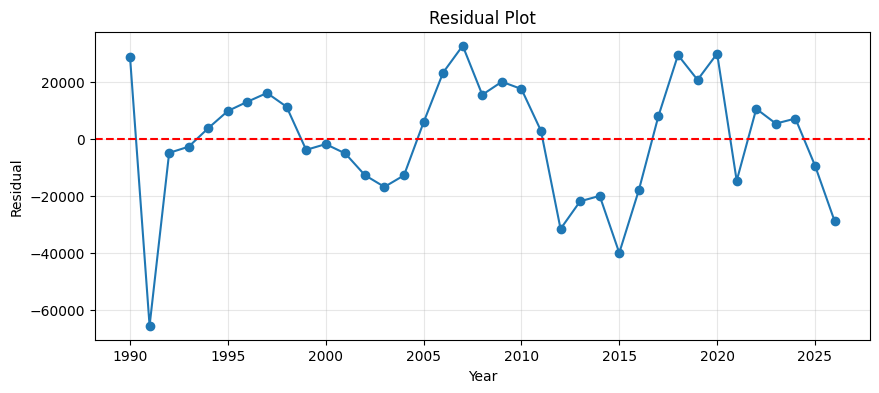

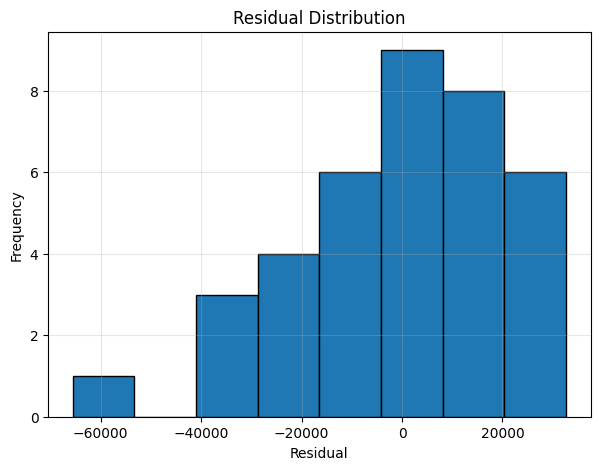


Durbin Watson : 1.282

INTERPRETATION
✗ Immediate level change is NOT statistically significant.
✗ Long-term trend change is NOT statistically significant.

Estimated Immediate Effect : 42703.87
Estimated Annual Trend Change : -1867.31


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

kuwait = df[df["Country"]=="Kuwait"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Domestic_Workers_Law_No_68"

policy_year = kuwait.loc[
    kuwait[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = kuwait[
    (kuwait["Year"] >= policy_year-3) &
    (kuwait["Year"] < policy_year)
]

after = kuwait[
    kuwait["Year"] >= policy_year
]

print("\nDESCRIPTIVE ANALYSIS")
print("-"*40)

print(before["Migration"].describe())
print()
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["3 Years Before","After Policy"],
    [before_mean,after_mean],
    width=.5
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Domestic_Workers_Law_No_68")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

kuwait["COVID"]=(kuwait["Year"]>=2020).astype(int)

kuwait["Year_Index"]=(
    kuwait["Year"]-
    kuwait["Year"].min()
)

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=kuwait[economic_variables]

X=X.fillna(X.median())

y=kuwait["Migration"]

# Standardize

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

# PCA

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(
    np.round(
        pca.explained_variance_ratio_,
        4
    )
)

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=kuwait.index
)

reg_data=pd.concat([

    pca_df,

    kuwait[[

        "Migration",
        "COVID",
        "Year_Index",
        policy

    ]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(

    formula,

    data=reg_data

).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\nPerformance")

print("----------------------")

print(

"R² :",

round(

r2_score(

reg_data["Migration"],
reg_data["Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

reg_data["Migration"],
reg_data["Prediction"]

)

),2)

)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

kuwait["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

kuwait["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("PCA Multiple Regression - Kuwaitization Policy")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.legend()

plt.grid(alpha=.3)

plt.show()

# ======================================================
# COEFFICIENT PLOT
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()



# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# KUWAITIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------
# Sort Data
# ------------------------------------------------------

kuwait = kuwait.sort_values("Year").copy()

# ------------------------------------------------------
# Time Variables
# ------------------------------------------------------

kuwait["Time"] = kuwait["Year"] - policy_year

# Policy Indicator

kuwait["Policy"] = (
    kuwait["Year"] >= policy_year
).astype(int)

# Time After Policy

kuwait["Time_After"] = (
    kuwait["Time"].clip(lower=0)
)

# Interaction

kuwait["Policy_Time"] = (
    kuwait["Policy"] *
    kuwait["Time_After"]
)

# COVID Variable

kuwait["COVID"] = (
    kuwait["Year"] >= 2020
).astype(int)

# ------------------------------------------------------
# Enhanced ITS Model
# ------------------------------------------------------

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=kuwait

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ------------------------------------------------------
# Prediction
# ------------------------------------------------------

kuwait["ITS_Prediction"] = its.predict(kuwait)

# ------------------------------------------------------
# Performance
# ------------------------------------------------------

print("\nITS PERFORMANCE")
print("-"*40)

print(

"R² :",

round(

r2_score(

kuwait["Migration"],
kuwait["ITS_Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

kuwait["Migration"],
kuwait["ITS_Prediction"]

)

),2)

)

# ------------------------------------------------------
# Policy Effect
# ------------------------------------------------------

print("\nPolicy Coefficients")
print("-"*40)

print("Level Change      :", round(its.params["Policy"],2))
print("Slope Change      :", round(its.params["Policy_Time"],2))
print("Time Effect       :", round(its.params["Time"],2))

print("\nP-values")
print("-"*40)

print("Policy      :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ------------------------------------------------------
# Observed vs ITS Prediction
# ------------------------------------------------------

plt.figure(figsize=(12,6))

plt.scatter(

kuwait["Year"],
kuwait["Migration"],

color="steelblue",

s=70,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

color="darkorange",

linewidth=3,

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Enhanced ITS - Kuwaitization Policy")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Counterfactual Prediction
# ------------------------------------------------------

counter = kuwait.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

kuwait["Year"],
kuwait["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

linewidth=3,

label="ITS"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Residual Plot
# ------------------------------------------------------

kuwait["Residuals"] = (

kuwait["Migration"] -

kuwait["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

kuwait["Year"],

kuwait["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Residual Histogram
# ------------------------------------------------------

plt.figure(figsize=(7,5))

plt.hist(

kuwait["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Durbin Watson
# ------------------------------------------------------

dw = durbin_watson(its.resid)

print("\nDurbin Watson :", round(dw,3))

# ------------------------------------------------------
# Interpretation
# ------------------------------------------------------

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Significant immediate level change after Kuwaitization Policy.")
else:
    print("✗ Immediate level change is NOT statistically significant.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ Significant long-term trend change after policy.")
else:
    print("✗ Long-term trend change is NOT statistically significant.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

kuwait third policy analysis

Policy : Residency_Law_Reforms
Policy Year : 2020

DESCRIPTIVE ANALYSIS
----------------------------------------
count          3.000000
mean      966666.666667
std        35118.845843
min       930000.000000
25%       950000.000000
50%       970000.000000
75%       985000.000000
max      1000000.000000
Name: Migration, dtype: float64

count    7.000000e+00
mean     1.005000e+06
std      3.366502e+04
min      9.500000e+05
25%      9.850000e+05
50%      1.010000e+06
75%      1.030000e+06
max      1.045000e+06
Name: Migration, dtype: float64

Mean Before : 966666.67
Mean After  : 1005000.0
Difference  : 38333.33


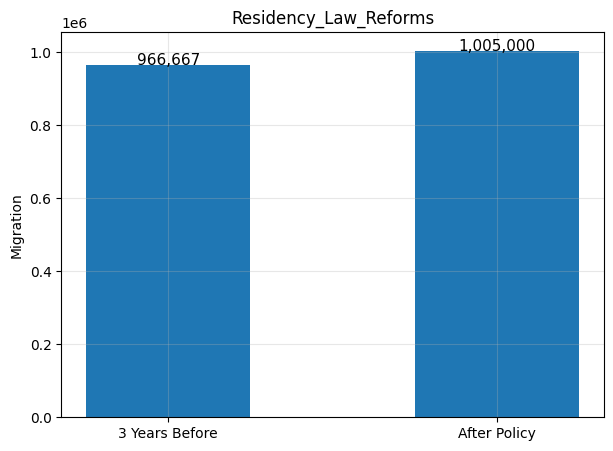


Variance Explained
[0.5729 0.2935 0.0862]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     1029.
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.81e-33
Time:                        02:50:12   Log-Likelihood:                -426.85
No. Observations:                  37   AIC:                             865.7
Df Residuals:                      31   BIC:                             875.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

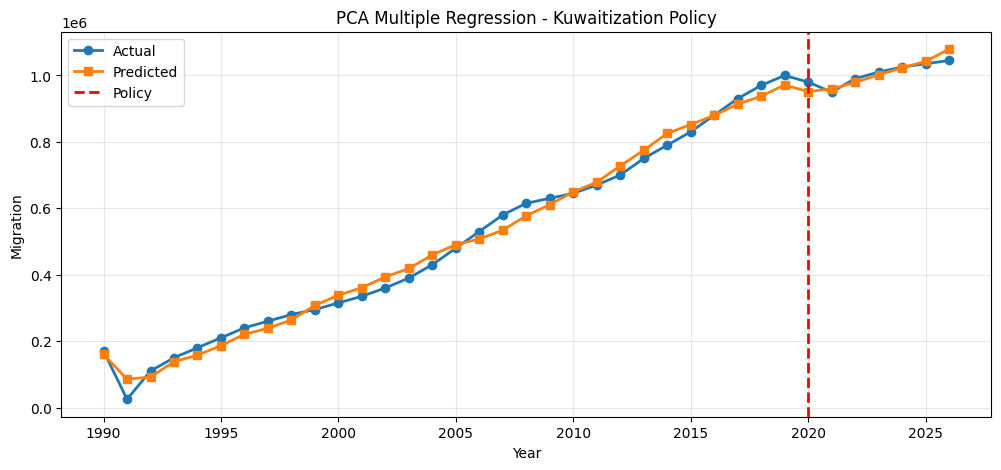

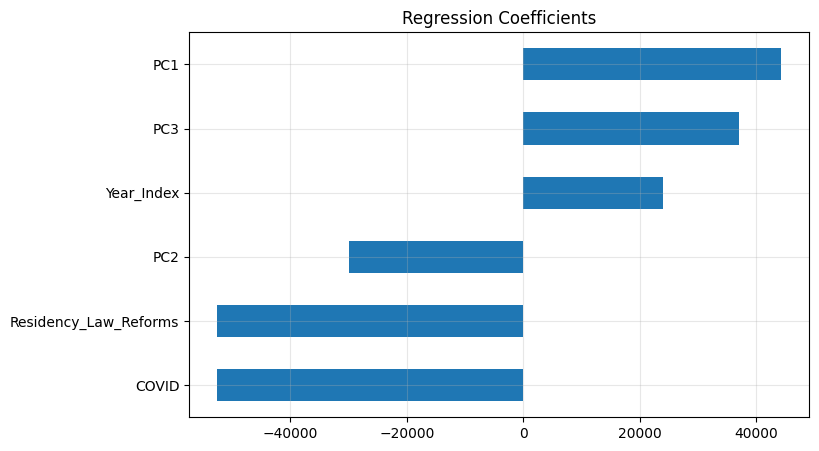

ENHANCED INTERRUPTED TIME SERIES
Policy : Residency_Law_Reforms
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     73.18
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           2.72e-16
Time:                        02:50:13   Log-Likelihood:                -417.56
No. Observations:                  37   AIC:                             855.1
Df Residuals:                      27   BIC:                             871.2
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 8
  warnings.warn('covariance of constraints does not have full '


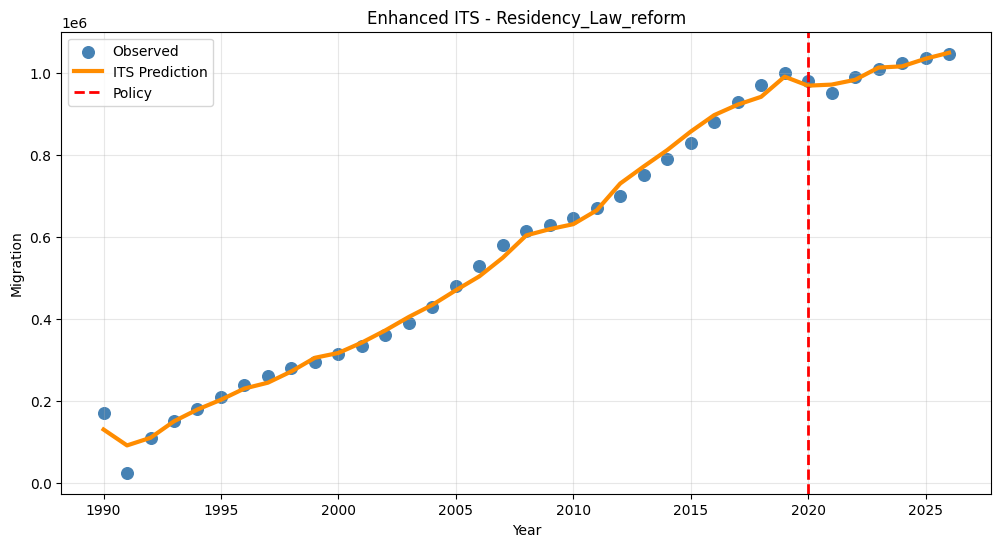

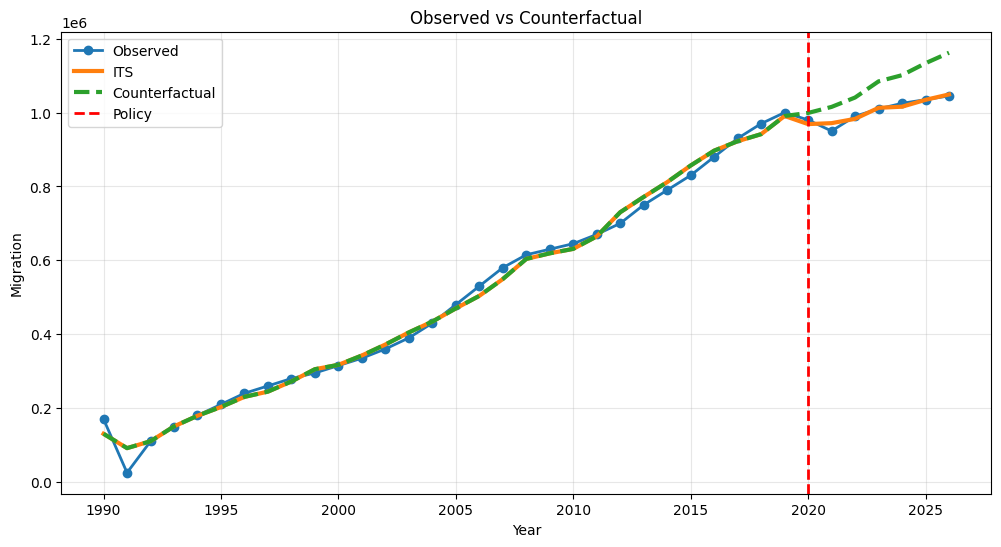

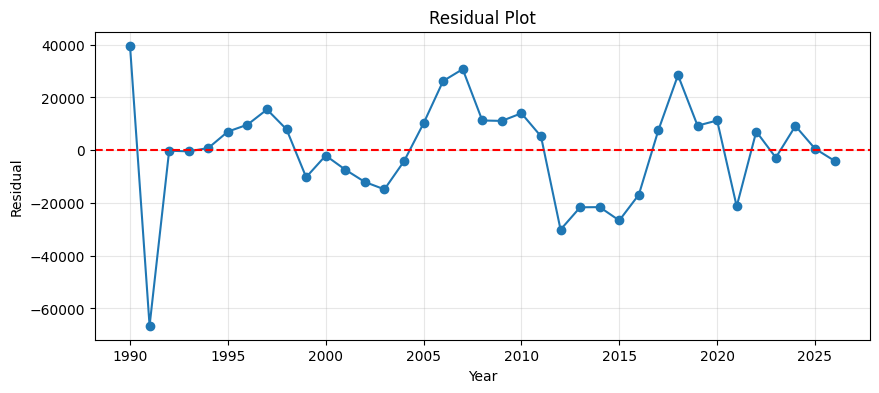

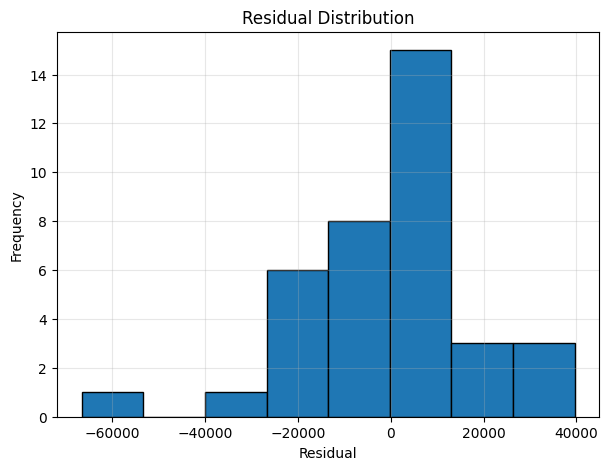


Durbin Watson : 1.63

INTERPRETATION
✓ Significant immediate level change after Residency_Law_Reforms.
✓ Significant long-term trend change after policy.

Estimated Immediate Effect : -30204.39
Estimated Annual Trend Change : -6893.19


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

kuwait = df[df["Country"]=="Kuwait"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Residency_Law_Reforms"

policy_year = kuwait.loc[
    kuwait[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = kuwait[
    (kuwait["Year"] >= policy_year-3) &
    (kuwait["Year"] < policy_year)
]

after = kuwait[
    kuwait["Year"] >= policy_year
]

print("\nDESCRIPTIVE ANALYSIS")
print("-"*40)

print(before["Migration"].describe())
print()
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["3 Years Before","After Policy"],
    [before_mean,after_mean],
    width=.5
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Residency_Law_Reforms")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

kuwait["COVID"]=(kuwait["Year"]>=2020).astype(int)

kuwait["Year_Index"]=(
    kuwait["Year"]-
    kuwait["Year"].min()
)

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=kuwait[economic_variables]

X=X.fillna(X.median())

y=kuwait["Migration"]

# Standardize

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

# PCA

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(
    np.round(
        pca.explained_variance_ratio_,
        4
    )
)

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=kuwait.index
)

reg_data=pd.concat([

    pca_df,

    kuwait[[

        "Migration",
        "COVID",
        "Year_Index",
        policy

    ]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(

    formula,

    data=reg_data

).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\nPerformance")

print("----------------------")

print(

"R² :",

round(

r2_score(

reg_data["Migration"],
reg_data["Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

reg_data["Migration"],
reg_data["Prediction"]

)

),2)

)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

kuwait["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

kuwait["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("PCA Multiple Regression - Kuwaitization Policy")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.legend()

plt.grid(alpha=.3)

plt.show()

# ======================================================
# COEFFICIENT PLOT
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()



# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# KUWAITIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------
# Sort Data
# ------------------------------------------------------

kuwait = kuwait.sort_values("Year").copy()

# ------------------------------------------------------
# Time Variables
# ------------------------------------------------------

kuwait["Time"] = kuwait["Year"] - policy_year

# Policy Indicator

kuwait["Policy"] = (
    kuwait["Year"] >= policy_year
).astype(int)

# Time After Policy

kuwait["Time_After"] = (
    kuwait["Time"].clip(lower=0)
)

# Interaction

kuwait["Policy_Time"] = (
    kuwait["Policy"] *
    kuwait["Time_After"]
)

# COVID Variable

kuwait["COVID"] = (
    kuwait["Year"] >= 2020
).astype(int)

# ------------------------------------------------------
# Enhanced ITS Model
# ------------------------------------------------------

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=kuwait

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ------------------------------------------------------
# Prediction
# ------------------------------------------------------

kuwait["ITS_Prediction"] = its.predict(kuwait)

# ------------------------------------------------------
# Performance
# ------------------------------------------------------

print("\nITS PERFORMANCE")
print("-"*40)

print(

"R² :",

round(

r2_score(

kuwait["Migration"],
kuwait["ITS_Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

kuwait["Migration"],
kuwait["ITS_Prediction"]

)

),2)

)

# ------------------------------------------------------
# Policy Effect
# ------------------------------------------------------

print("\nPolicy Coefficients")
print("-"*40)

print("Level Change      :", round(its.params["Policy"],2))
print("Slope Change      :", round(its.params["Policy_Time"],2))
print("Time Effect       :", round(its.params["Time"],2))

print("\nP-values")
print("-"*40)

print("Policy      :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ------------------------------------------------------
# Observed vs ITS Prediction
# ------------------------------------------------------

plt.figure(figsize=(12,6))

plt.scatter(

kuwait["Year"],
kuwait["Migration"],

color="steelblue",

s=70,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

color="darkorange",

linewidth=3,

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Enhanced ITS - Residency_Law_reform")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Counterfactual Prediction
# ------------------------------------------------------

counter = kuwait.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

kuwait["Year"],
kuwait["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

linewidth=3,

label="ITS"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Residual Plot
# ------------------------------------------------------

kuwait["Residuals"] = (

kuwait["Migration"] -

kuwait["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

kuwait["Year"],

kuwait["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Residual Histogram
# ------------------------------------------------------

plt.figure(figsize=(7,5))

plt.hist(

kuwait["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Durbin Watson
# ------------------------------------------------------

dw = durbin_watson(its.resid)

print("\nDurbin Watson :", round(dw,3))

# ------------------------------------------------------
# Interpretation
# ------------------------------------------------------

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Significant immediate level change after Residency_Law_Reforms.")
else:
    print("✗ Immediate level change is NOT statistically significant.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ Significant long-term trend change after policy.")
else:
    print("✗ Long-term trend change is NOT statistically significant.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

fourth policy

Policy : Labour_Market_Reform
Policy Year : 2024

DESCRIPTIVE ANALYSIS
----------------------------------------
count    3.000000e+00
mean     9.833333e+05
std      3.055050e+04
min      9.500000e+05
25%      9.700000e+05
50%      9.900000e+05
75%      1.000000e+06
max      1.010000e+06
Name: Migration, dtype: float64

count          3.0
mean     1035000.0
std        10000.0
min      1025000.0
25%      1030000.0
50%      1035000.0
75%      1040000.0
max      1045000.0
Name: Migration, dtype: float64

Mean Before : 983333.33
Mean After  : 1035000.0
Difference  : 51666.67


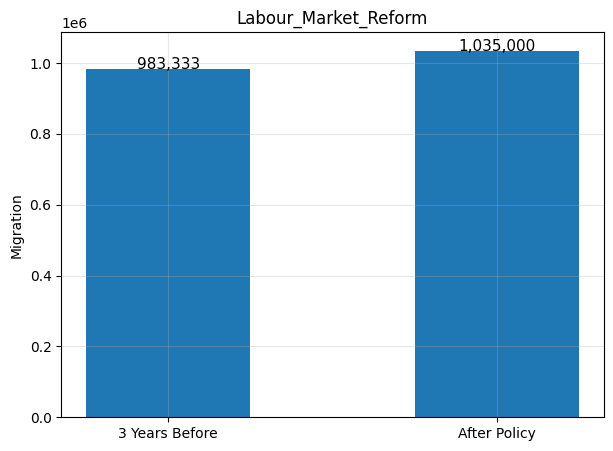


Variance Explained
[0.5729 0.2935 0.0862]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     866.9
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           3.21e-32
Time:                        02:50:18   Log-Likelihood:                -426.05
No. Observations:                  37   AIC:                             866.1
Df Residuals:                      30   BIC:                             877.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

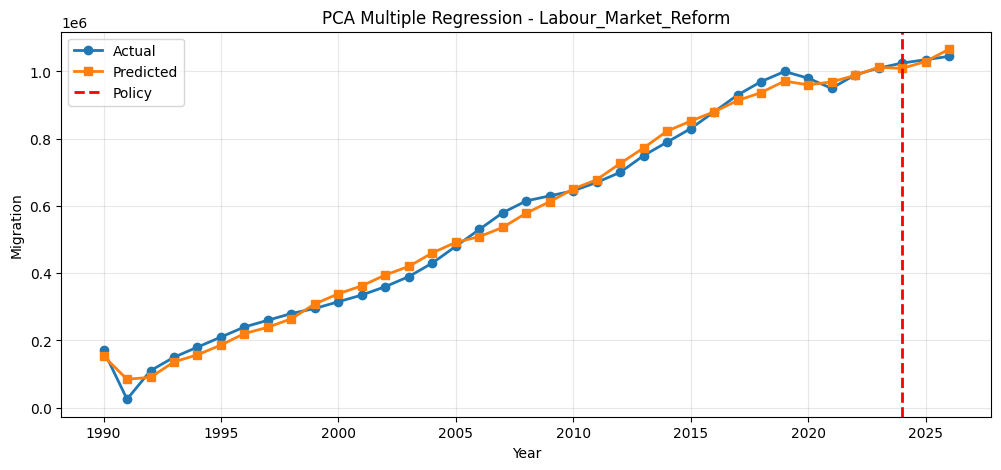

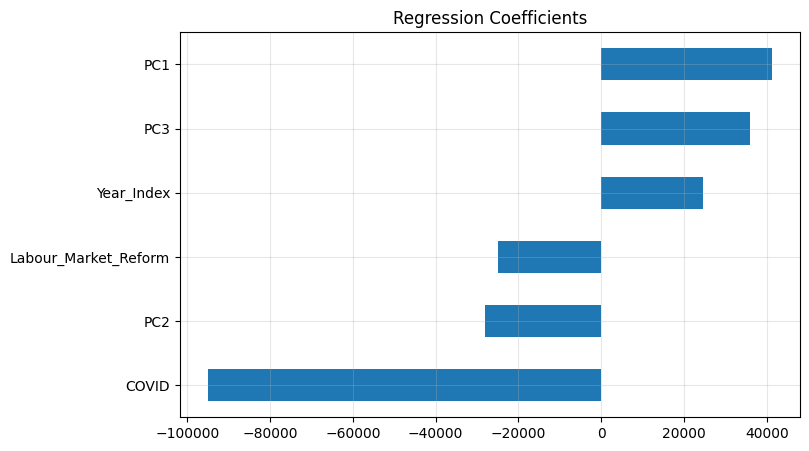

ENHANCED INTERRUPTED TIME SERIES
Policy : Labour_Market_Reform
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     173.6
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           6.79e-21
Time:                        02:50:19   Log-Likelihood:                -418.02
No. Observations:                  37   AIC:                             858.0
Df Residuals:                      26   BIC:                             875.8
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


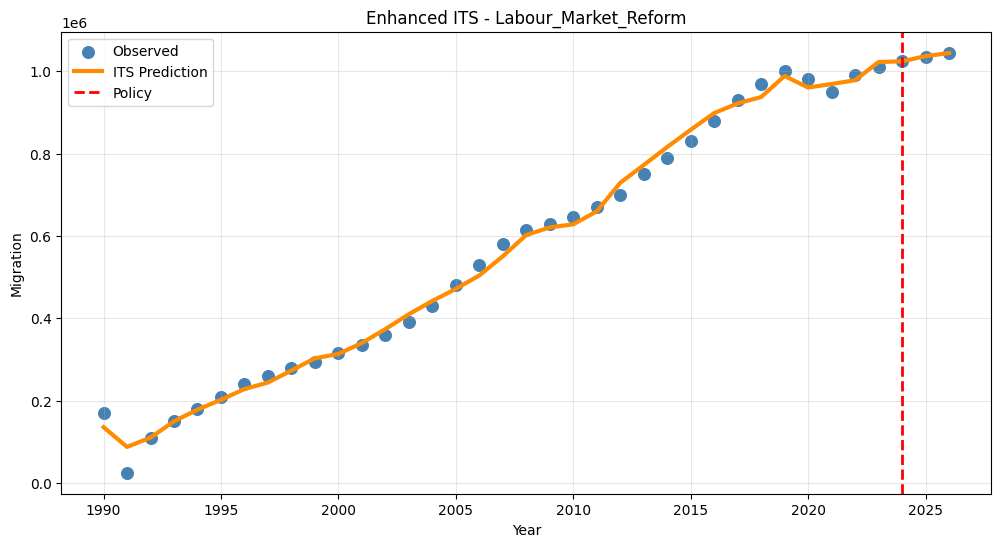

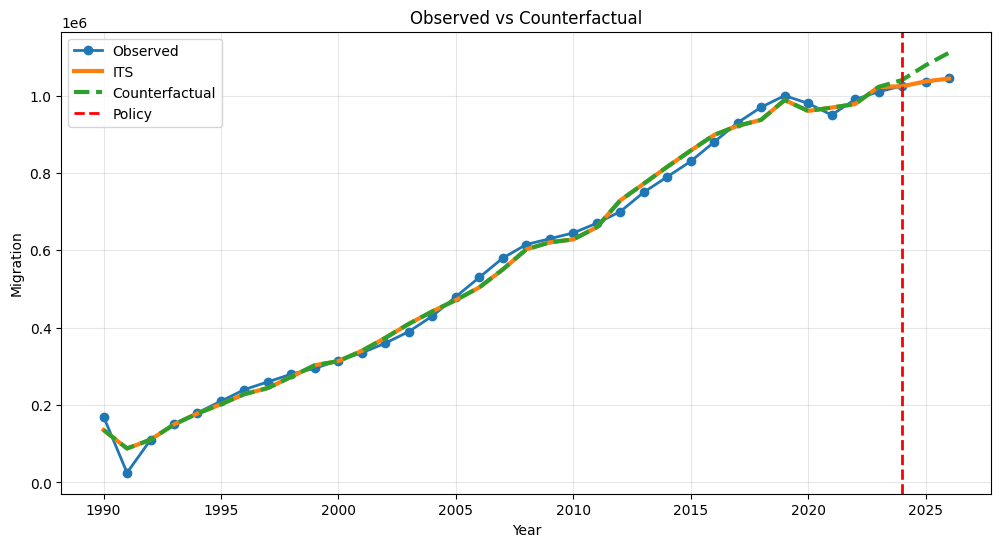

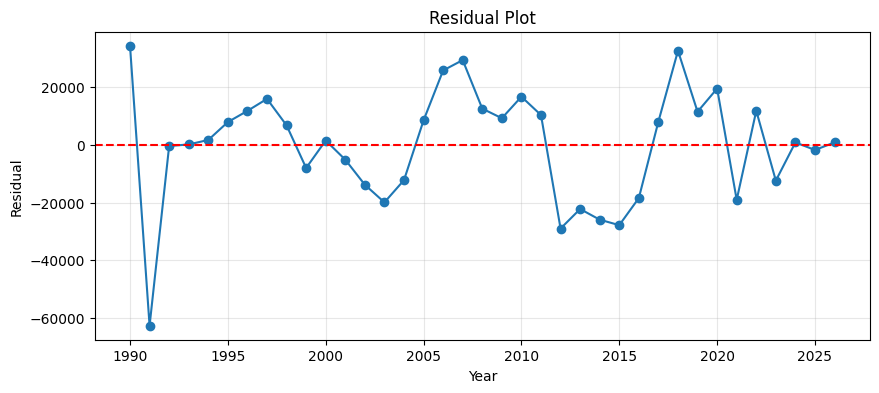

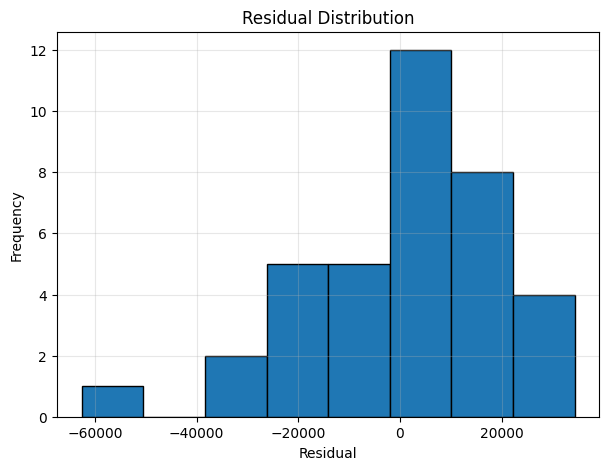


Durbin Watson : 1.549

INTERPRETATION
✗ Immediate level change is NOT statistically significant.
✓ Significant long-term trend change after policy.

Estimated Immediate Effect : -16247.8
Estimated Annual Trend Change : -12633.33


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

kuwait = df[df["Country"]=="Kuwait"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Labour_Market_Reform"

policy_year = kuwait.loc[
    kuwait[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = kuwait[
    (kuwait["Year"] >= policy_year-3) &
    (kuwait["Year"] < policy_year)
]

after = kuwait[
    kuwait["Year"] >= policy_year
]

print("\nDESCRIPTIVE ANALYSIS")
print("-"*40)

print(before["Migration"].describe())
print()
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["3 Years Before","After Policy"],
    [before_mean,after_mean],
    width=.5
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Labour_Market_Reform")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

kuwait["COVID"]=(kuwait["Year"]>=2020).astype(int)

kuwait["Year_Index"]=(
    kuwait["Year"]-
    kuwait["Year"].min()
)

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=kuwait[economic_variables]

X=X.fillna(X.median())

y=kuwait["Migration"]

# Standardize

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

# PCA

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(
    np.round(
        pca.explained_variance_ratio_,
        4
    )
)

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=kuwait.index
)

reg_data=pd.concat([

    pca_df,

    kuwait[[

        "Migration",
        "COVID",
        "Year_Index",
        policy

    ]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(

    formula,

    data=reg_data

).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\nPerformance")

print("----------------------")

print(

"R² :",

round(

r2_score(

reg_data["Migration"],
reg_data["Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

reg_data["Migration"],
reg_data["Prediction"]

)

),2)

)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

kuwait["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

kuwait["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("PCA Multiple Regression - Labour_Market_Reform")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.legend()

plt.grid(alpha=.3)

plt.show()

# ======================================================
# COEFFICIENT PLOT
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()



# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# KUWAITIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------
# Sort Data
# ------------------------------------------------------

kuwait = kuwait.sort_values("Year").copy()

# ------------------------------------------------------
# Time Variables
# ------------------------------------------------------

kuwait["Time"] = kuwait["Year"] - policy_year

# Policy Indicator

kuwait["Policy"] = (
    kuwait["Year"] >= policy_year
).astype(int)

# Time After Policy

kuwait["Time_After"] = (
    kuwait["Time"].clip(lower=0)
)

# Interaction

kuwait["Policy_Time"] = (
    kuwait["Policy"] *
    kuwait["Time_After"]
)

# COVID Variable

kuwait["COVID"] = (
    kuwait["Year"] >= 2020
).astype(int)

# ------------------------------------------------------
# Enhanced ITS Model
# ------------------------------------------------------

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=kuwait

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ------------------------------------------------------
# Prediction
# ------------------------------------------------------

kuwait["ITS_Prediction"] = its.predict(kuwait)

# ------------------------------------------------------
# Performance
# ------------------------------------------------------

print("\nITS PERFORMANCE")
print("-"*40)

print(

"R² :",

round(

r2_score(

kuwait["Migration"],
kuwait["ITS_Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

kuwait["Migration"],
kuwait["ITS_Prediction"]

)

),2)

)

# ------------------------------------------------------
# Policy Effect
# ------------------------------------------------------

print("\nPolicy Coefficients")
print("-"*40)

print("Level Change      :", round(its.params["Policy"],2))
print("Slope Change      :", round(its.params["Policy_Time"],2))
print("Time Effect       :", round(its.params["Time"],2))

print("\nP-values")
print("-"*40)

print("Policy      :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ------------------------------------------------------
# Observed vs ITS Prediction
# ------------------------------------------------------

plt.figure(figsize=(12,6))

plt.scatter(

kuwait["Year"],
kuwait["Migration"],

color="steelblue",

s=70,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

color="darkorange",

linewidth=3,

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Enhanced ITS - Labour_Market_Reform")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Counterfactual Prediction
# ------------------------------------------------------

counter = kuwait.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

kuwait["Year"],
kuwait["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

linewidth=3,

label="ITS"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Residual Plot
# ------------------------------------------------------

kuwait["Residuals"] = (

kuwait["Migration"] -

kuwait["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

kuwait["Year"],

kuwait["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Residual Histogram
# ------------------------------------------------------

plt.figure(figsize=(7,5))

plt.hist(

kuwait["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Durbin Watson
# ------------------------------------------------------

dw = durbin_watson(its.resid)

print("\nDurbin Watson :", round(dw,3))

# ------------------------------------------------------
# Interpretation
# ------------------------------------------------------

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Significant immediate level change after Residency_Law_Reforms.")
else:
    print("✗ Immediate level change is NOT statistically significant.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ Significant long-term trend change after policy.")
else:
    print("✗ Long-term trend change is NOT statistically significant.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

In [ ]:
df.columns

Index(['Country', 'Year', 'GDP', 'Inflation', 'Population', 'Migration',
       'Migration_Flow', 'Oil_Price', 'Exchange_Rate', 'Unemployment',
       'Kafala_Sponsorship_System', 'Kuwaitization_Policy',
       'Domestic_Workers_Law_No_68', 'Residency_Law_Reforms',
       'Labour_Market_Reform', 'Privat_Sector_Labor_Law',
       'Foreigners_Residency_Law_No_114', 'Omanisation_Policy',
       'Labour_Law_Royal_Decree_35', 'Visa_Ban_Policy',
       'Expansion_of_Omanisation', 'Labour_Law_Reform_2023',
       'Bahrainization_Policy', 'Labour_Market_Reform_Law_2006',
       'Labour_Law_No_36', 'Flexi_Permit', 'Labour_Registration_Program'],
      dtype='object')

kuwait fifth policy anlysis

Policy : Privat_Sector_Labor_Law
Policy Year : 2010

DESCRIPTIVE ANALYSIS
----------------------------------------
count         3.000000
mean     608333.333333
std       25658.007197
min      580000.000000
25%      597500.000000
50%      615000.000000
75%      622500.000000
max      630000.000000
Name: Migration, dtype: float64

count    1.700000e+01
mean     8.941176e+05
std      1.362470e+05
min      6.450000e+05
25%      7.900000e+05
50%      9.500000e+05
75%      1.000000e+06
max      1.045000e+06
Name: Migration, dtype: float64

Mean Before : 608333.33
Mean After  : 894117.65
Difference  : 285784.31


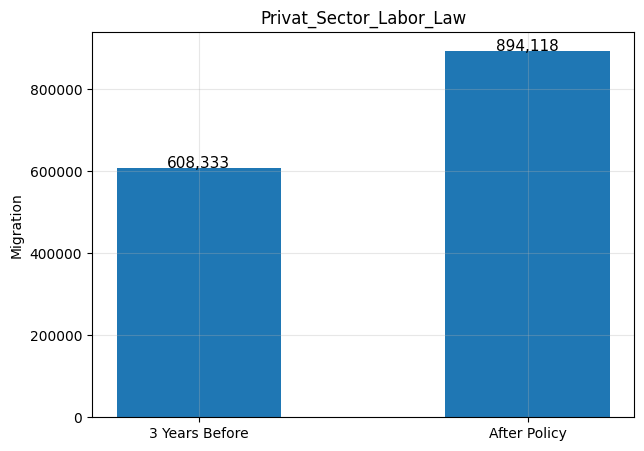


Variance Explained
[0.5729 0.2935 0.0862]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     831.9
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           5.93e-32
Time:                        02:50:23   Log-Likelihood:                -426.81
No. Observations:                  37   AIC:                             867.6
Df Residuals:                      30   BIC:                             878.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

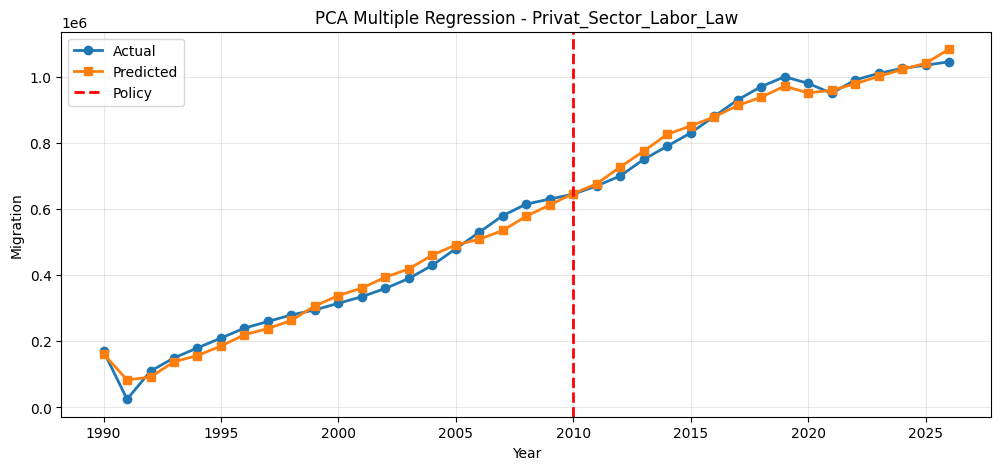

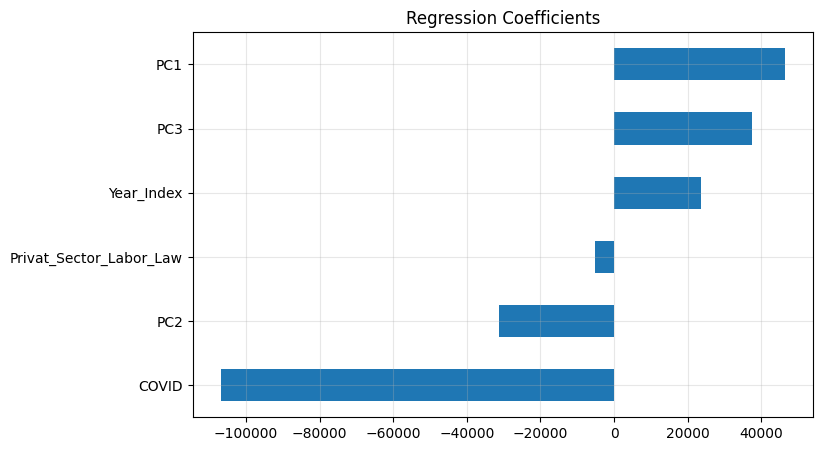

ENHANCED INTERRUPTED TIME SERIES
Policy : Privat_Sector_Labor_Law
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     57.38
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           7.11e-15
Time:                        02:50:24   Log-Likelihood:                -411.83
No. Observations:                  37   AIC:                             845.7
Df Residuals:                      26   BIC:                             863.4
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


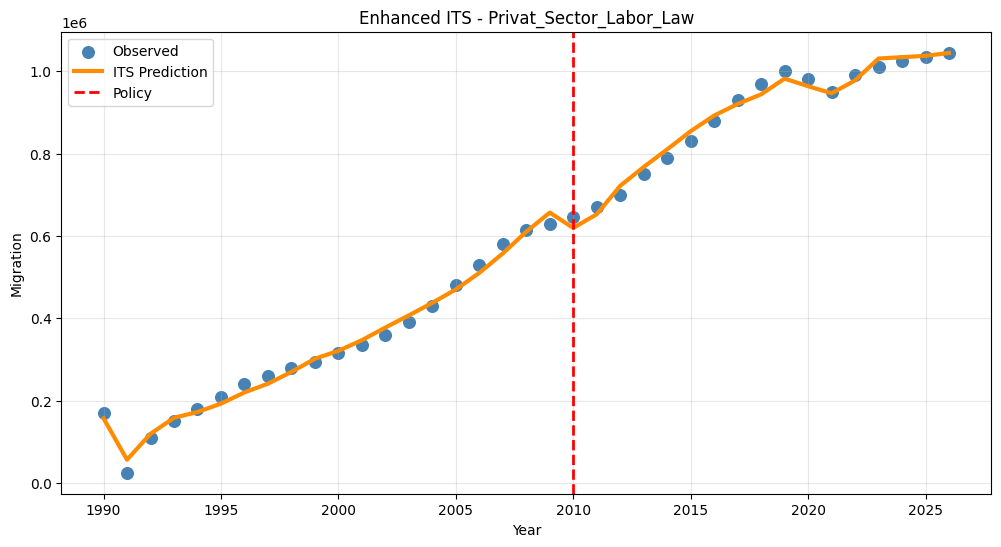

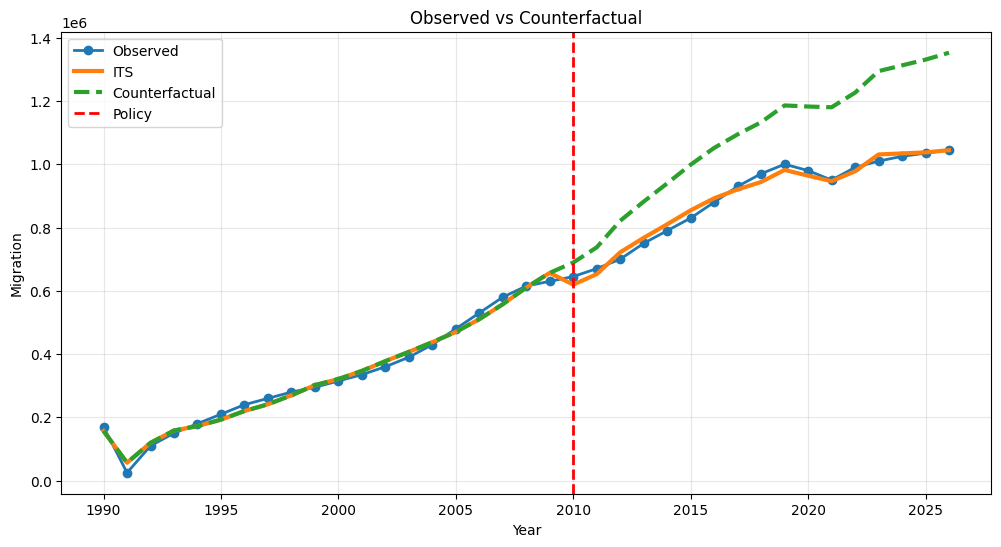

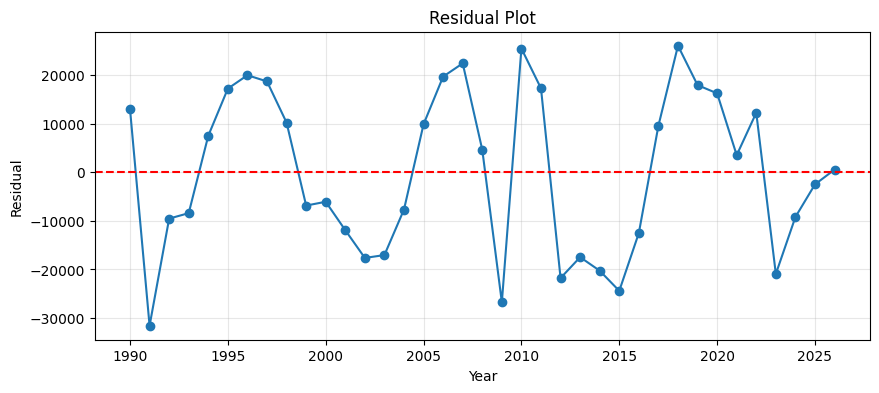

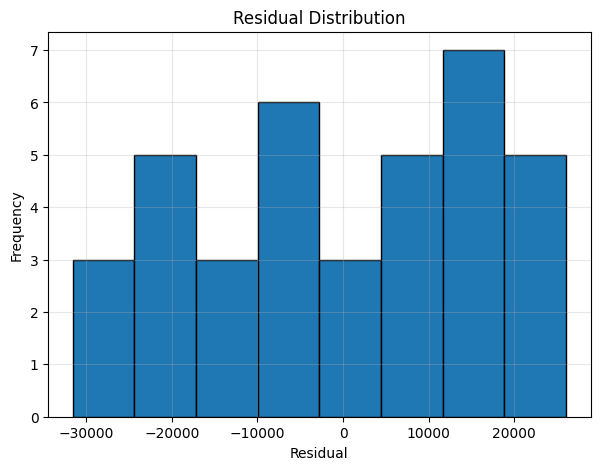


Durbin Watson : 1.183

INTERPRETATION
✓ Significant immediate level change after Privat_Sector_Labor_Law
✓ Significant long-term trend change after policy.

Estimated Immediate Effect : -69774.66
Estimated Annual Trend Change : -7446.01


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

kuwait = df[df["Country"]=="Kuwait"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Privat_Sector_Labor_Law"

policy_year = kuwait.loc[
    kuwait[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = kuwait[
    (kuwait["Year"] >= policy_year-3) &
    (kuwait["Year"] < policy_year)
]

after = kuwait[
    kuwait["Year"] >= policy_year
]

print("\nDESCRIPTIVE ANALYSIS")
print("-"*40)

print(before["Migration"].describe())
print()
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["3 Years Before","After Policy"],
    [before_mean,after_mean],
    width=.5
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Privat_Sector_Labor_Law")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

kuwait["COVID"]=(kuwait["Year"]>=2020).astype(int)

kuwait["Year_Index"]=(
    kuwait["Year"]-
    kuwait["Year"].min()
)

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=kuwait[economic_variables]

X=X.fillna(X.median())

y=kuwait["Migration"]

# Standardize

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

# PCA

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(
    np.round(
        pca.explained_variance_ratio_,
        4
    )
)

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=kuwait.index
)

reg_data=pd.concat([

    pca_df,

    kuwait[[

        "Migration",
        "COVID",
        "Year_Index",
        policy

    ]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(

    formula,

    data=reg_data

).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\nPerformance")

print("----------------------")

print(

"R² :",

round(

r2_score(

reg_data["Migration"],
reg_data["Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

reg_data["Migration"],
reg_data["Prediction"]

)

),2)

)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

kuwait["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

kuwait["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("PCA Multiple Regression - Privat_Sector_Labor_Law")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.legend()

plt.grid(alpha=.3)

plt.show()

# ======================================================
# COEFFICIENT PLOT
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()



# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# KUWAITIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------
# Sort Data
# ------------------------------------------------------

kuwait = kuwait.sort_values("Year").copy()

# ------------------------------------------------------
# Time Variables
# ------------------------------------------------------

kuwait["Time"] = kuwait["Year"] - policy_year

# Policy Indicator

kuwait["Policy"] = (
    kuwait["Year"] >= policy_year
).astype(int)

# Time After Policy

kuwait["Time_After"] = (
    kuwait["Time"].clip(lower=0)
)

# Interaction

kuwait["Policy_Time"] = (
    kuwait["Policy"] *
    kuwait["Time_After"]
)

# COVID Variable

kuwait["COVID"] = (
    kuwait["Year"] >= 2020
).astype(int)

# ------------------------------------------------------
# Enhanced ITS Model
# ------------------------------------------------------

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=kuwait

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ------------------------------------------------------
# Prediction
# ------------------------------------------------------

kuwait["ITS_Prediction"] = its.predict(kuwait)

# ------------------------------------------------------
# Performance
# ------------------------------------------------------

print("\nITS PERFORMANCE")
print("-"*40)

print(

"R² :",

round(

r2_score(

kuwait["Migration"],
kuwait["ITS_Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

kuwait["Migration"],
kuwait["ITS_Prediction"]

)

),2)

)

# ------------------------------------------------------
# Policy Effect
# ------------------------------------------------------

print("\nPolicy Coefficients")
print("-"*40)

print("Level Change      :", round(its.params["Policy"],2))
print("Slope Change      :", round(its.params["Policy_Time"],2))
print("Time Effect       :", round(its.params["Time"],2))

print("\nP-values")
print("-"*40)

print("Policy      :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ------------------------------------------------------
# Observed vs ITS Prediction
# ------------------------------------------------------

plt.figure(figsize=(12,6))

plt.scatter(

kuwait["Year"],
kuwait["Migration"],

color="steelblue",

s=70,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

color="darkorange",

linewidth=3,

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Enhanced ITS - Privat_Sector_Labor_Law")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Counterfactual Prediction
# ------------------------------------------------------

counter = kuwait.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

kuwait["Year"],
kuwait["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

linewidth=3,

label="ITS"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Residual Plot
# ------------------------------------------------------

kuwait["Residuals"] = (

kuwait["Migration"] -

kuwait["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

kuwait["Year"],

kuwait["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Residual Histogram
# ------------------------------------------------------

plt.figure(figsize=(7,5))

plt.hist(

kuwait["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Durbin Watson
# ------------------------------------------------------

dw = durbin_watson(its.resid)

print("\nDurbin Watson :", round(dw,3))

# ------------------------------------------------------
# Interpretation
# ------------------------------------------------------

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Significant immediate level change after Privat_Sector_Labor_Law")
else:
    print("✗ Immediate level change is NOT statistically significant.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ Significant long-term trend change after policy.")
else:
    print("✗ Long-term trend change is NOT statistically significant.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

sixth policy anlysis of kuwait

Policy : Foreigners_Residency_Law_No_114
Policy Year : 2024

DESCRIPTIVE ANALYSIS
----------------------------------------
count    3.000000e+00
mean     9.833333e+05
std      3.055050e+04
min      9.500000e+05
25%      9.700000e+05
50%      9.900000e+05
75%      1.000000e+06
max      1.010000e+06
Name: Migration, dtype: float64

count          3.0
mean     1035000.0
std        10000.0
min      1025000.0
25%      1030000.0
50%      1035000.0
75%      1040000.0
max      1045000.0
Name: Migration, dtype: float64

Mean Before : 983333.33
Mean After  : 1035000.0
Difference  : 51666.67


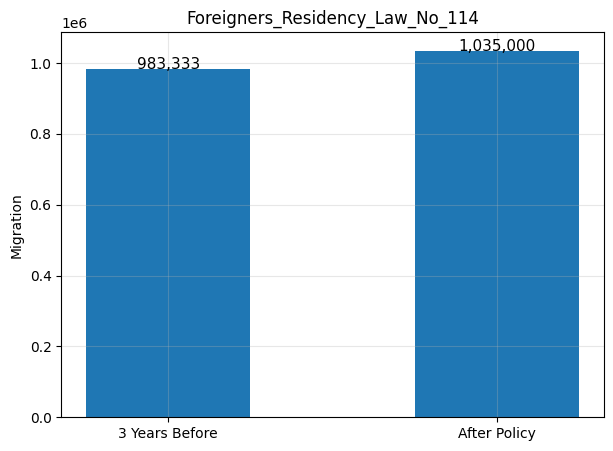


Variance Explained
[0.5729 0.2935 0.0862]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     866.9
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           3.21e-32
Time:                        02:50:27   Log-Likelihood:                -426.05
No. Observations:                  37   AIC:                             866.1
Df Residuals:                      30   BIC:                             877.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

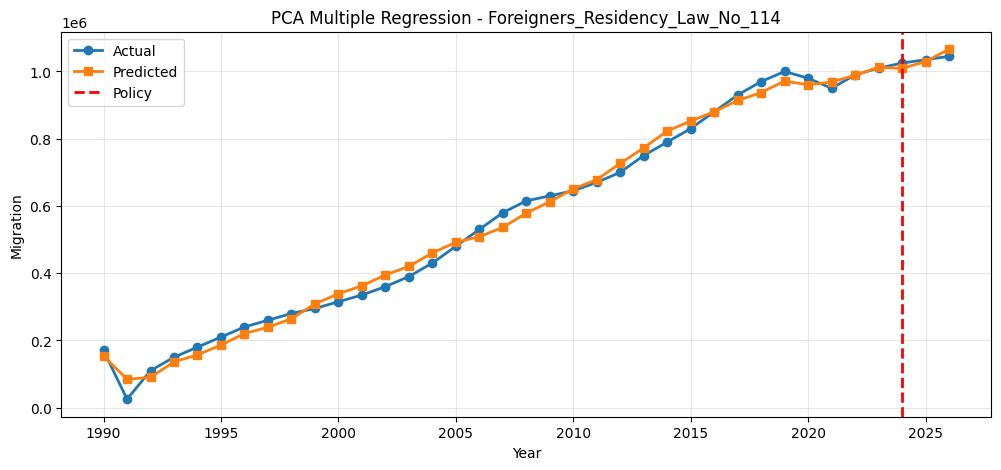

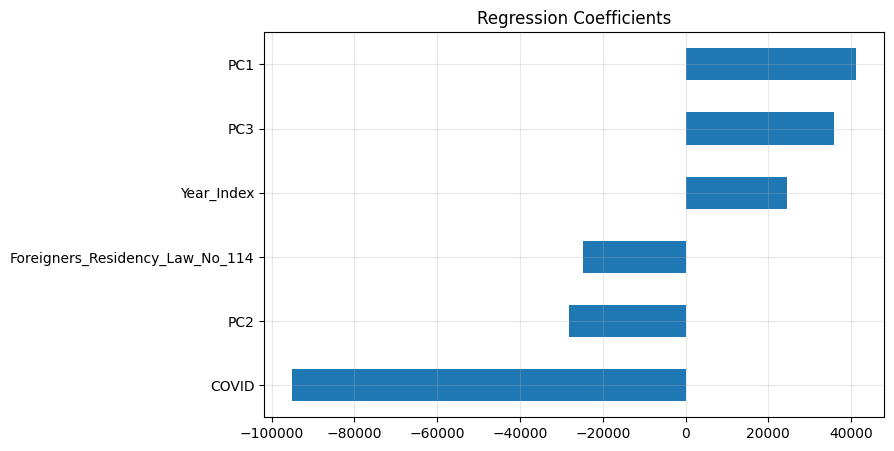

ENHANCED INTERRUPTED TIME SERIES
Policy : Foreigners_Residency_Law_No_114
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     173.6
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           6.79e-21
Time:                        02:50:27   Log-Likelihood:                -418.02
No. Observations:                  37   AIC:                             858.0
Df Residuals:                      26   BIC:                             875.8
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


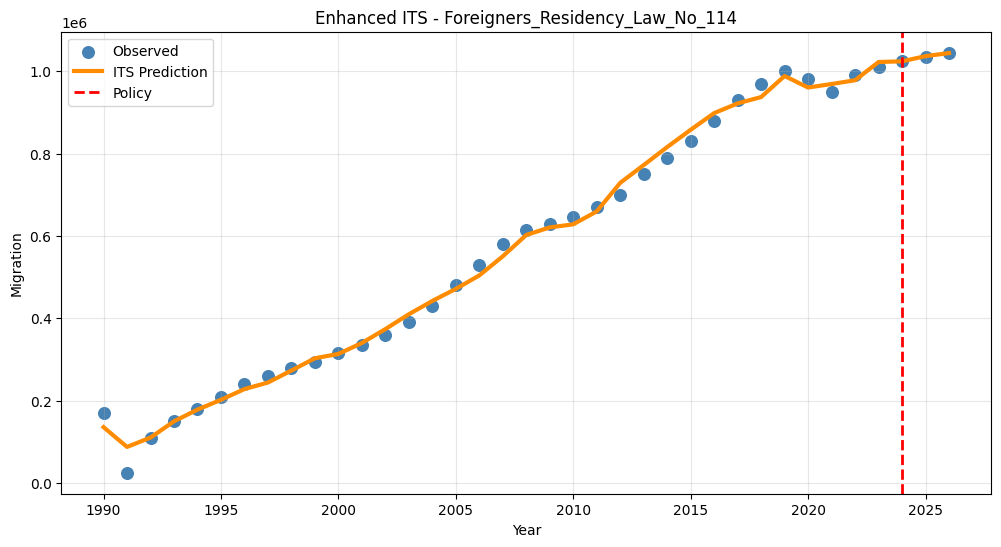

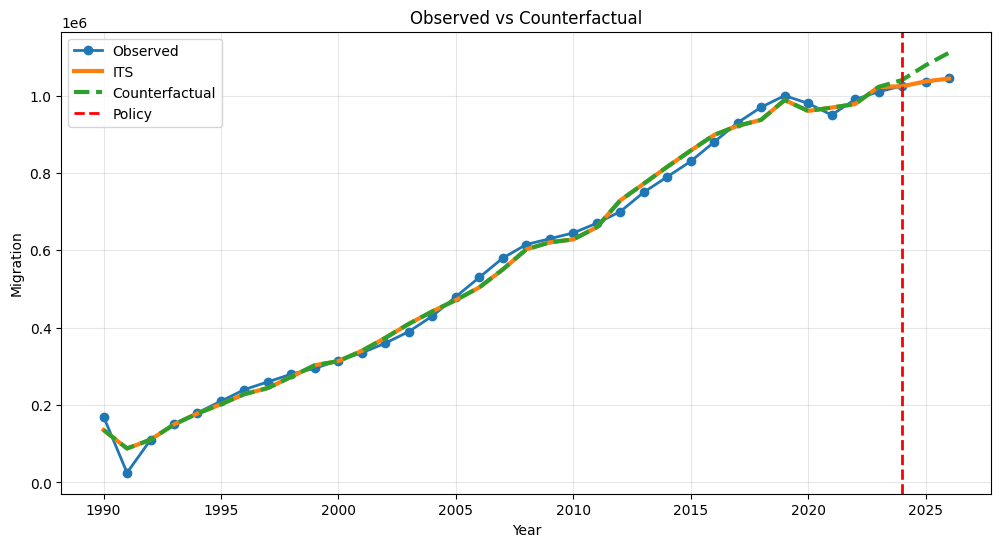

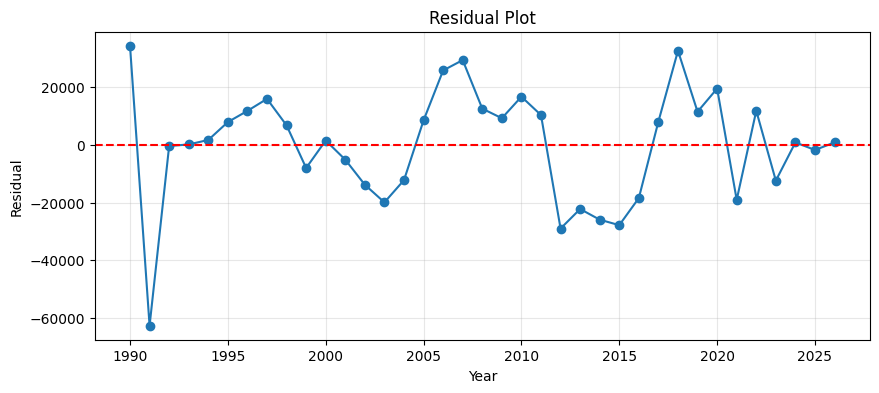

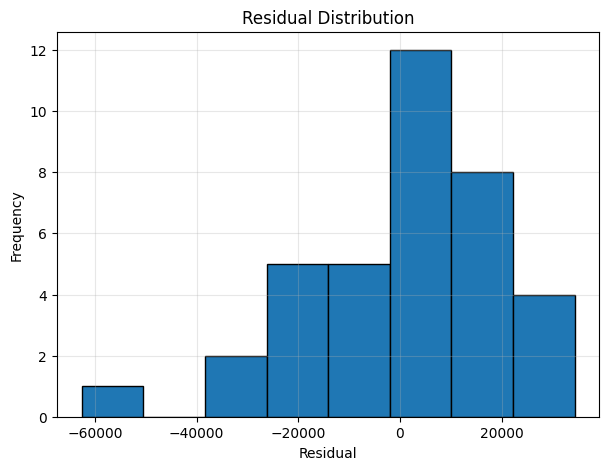


Durbin Watson : 1.549

INTERPRETATION
✗ Immediate level change is NOT statistically significant.
✓ Significant long-term trend change after policy.

Estimated Immediate Effect : -16247.8
Estimated Annual Trend Change : -12633.33


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

kuwait = df[df["Country"]=="Kuwait"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Foreigners_Residency_Law_No_114"

policy_year = kuwait.loc[
    kuwait[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = kuwait[
    (kuwait["Year"] >= policy_year-3) &
    (kuwait["Year"] < policy_year)
]

after = kuwait[
    kuwait["Year"] >= policy_year
]

print("\nDESCRIPTIVE ANALYSIS")
print("-"*40)

print(before["Migration"].describe())
print()
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["3 Years Before","After Policy"],
    [before_mean,after_mean],
    width=.5
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Foreigners_Residency_Law_No_114")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

kuwait["COVID"]=(kuwait["Year"]>=2020).astype(int)

kuwait["Year_Index"]=(
    kuwait["Year"]-
    kuwait["Year"].min()
)

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=kuwait[economic_variables]

X=X.fillna(X.median())

y=kuwait["Migration"]

# Standardize

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

# PCA

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(
    np.round(
        pca.explained_variance_ratio_,
        4
    )
)

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=kuwait.index
)

reg_data=pd.concat([

    pca_df,

    kuwait[[

        "Migration",
        "COVID",
        "Year_Index",
        policy

    ]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(

    formula,

    data=reg_data

).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\nPerformance")

print("----------------------")

print(

"R² :",

round(

r2_score(

reg_data["Migration"],
reg_data["Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

reg_data["Migration"],
reg_data["Prediction"]

)

),2)

)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

kuwait["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

kuwait["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("PCA Multiple Regression - Foreigners_Residency_Law_No_114")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.legend()

plt.grid(alpha=.3)

plt.show()

# ======================================================
# COEFFICIENT PLOT
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()



# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# KUWAITIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------
# Sort Data
# ------------------------------------------------------

kuwait = kuwait.sort_values("Year").copy()

# ------------------------------------------------------
# Time Variables
# ------------------------------------------------------

kuwait["Time"] = kuwait["Year"] - policy_year

# Policy Indicator

kuwait["Policy"] = (
    kuwait["Year"] >= policy_year
).astype(int)

# Time After Policy

kuwait["Time_After"] = (
    kuwait["Time"].clip(lower=0)
)

# Interaction

kuwait["Policy_Time"] = (
    kuwait["Policy"] *
    kuwait["Time_After"]
)

# COVID Variable

kuwait["COVID"] = (
    kuwait["Year"] >= 2020
).astype(int)

# ------------------------------------------------------
# Enhanced ITS Model
# ------------------------------------------------------

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=kuwait

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ------------------------------------------------------
# Prediction
# ------------------------------------------------------

kuwait["ITS_Prediction"] = its.predict(kuwait)

# ------------------------------------------------------
# Performance
# ------------------------------------------------------

print("\nITS PERFORMANCE")
print("-"*40)

print(

"R² :",

round(

r2_score(

kuwait["Migration"],
kuwait["ITS_Prediction"]

),4)

)

print(

"RMSE :",

round(

np.sqrt(

mean_squared_error(

kuwait["Migration"],
kuwait["ITS_Prediction"]

)

),2)

)

# ------------------------------------------------------
# Policy Effect
# ------------------------------------------------------

print("\nPolicy Coefficients")
print("-"*40)

print("Level Change      :", round(its.params["Policy"],2))
print("Slope Change      :", round(its.params["Policy_Time"],2))
print("Time Effect       :", round(its.params["Time"],2))

print("\nP-values")
print("-"*40)

print("Policy      :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ------------------------------------------------------
# Observed vs ITS Prediction
# ------------------------------------------------------

plt.figure(figsize=(12,6))

plt.scatter(

kuwait["Year"],
kuwait["Migration"],

color="steelblue",

s=70,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

color="darkorange",

linewidth=3,

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Enhanced ITS - Foreigners_Residency_Law_No_114")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Counterfactual Prediction
# ------------------------------------------------------

counter = kuwait.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

kuwait["Year"],
kuwait["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

kuwait["Year"],
kuwait["ITS_Prediction"],

linewidth=3,

label="ITS"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ------------------------------------------------------
# Residual Plot
# ------------------------------------------------------

kuwait["Residuals"] = (

kuwait["Migration"] -

kuwait["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

kuwait["Year"],

kuwait["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Residual Histogram
# ------------------------------------------------------

plt.figure(figsize=(7,5))

plt.hist(

kuwait["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ------------------------------------------------------
# Durbin Watson
# ------------------------------------------------------

dw = durbin_watson(its.resid)

print("\nDurbin Watson :", round(dw,3))

# ------------------------------------------------------
# Interpretation
# ------------------------------------------------------

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Significant immediate level change after Privat_Sector_Labor_Law")
else:
    print("✗ Immediate level change is NOT statistically significant.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ Significant long-term trend change after policy.")
else:
    print("✗ Long-term trend change is NOT statistically significant.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

prophet model for kwaitm


========== KUWAIT FORECAST (2027-2030) ==========

    Year Predicted_Migration Lower_Bound Upper_Bound
37  2027           1,061,940   1,032,215   1,093,076
38  2028           1,074,801   1,043,271   1,107,092
39  2029           1,087,698   1,056,315   1,121,617
40  2030           1,100,559   1,067,949   1,135,899


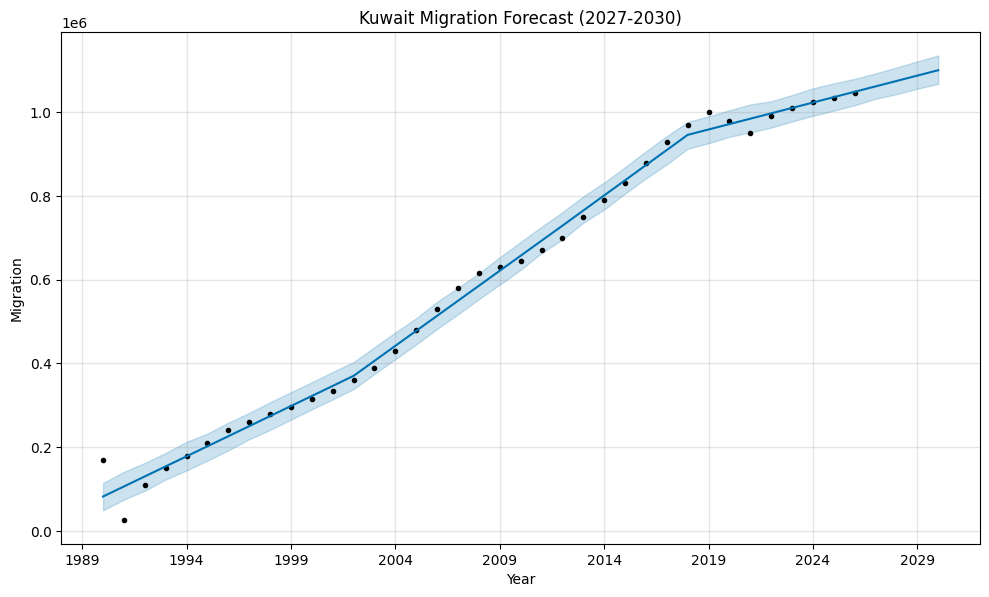

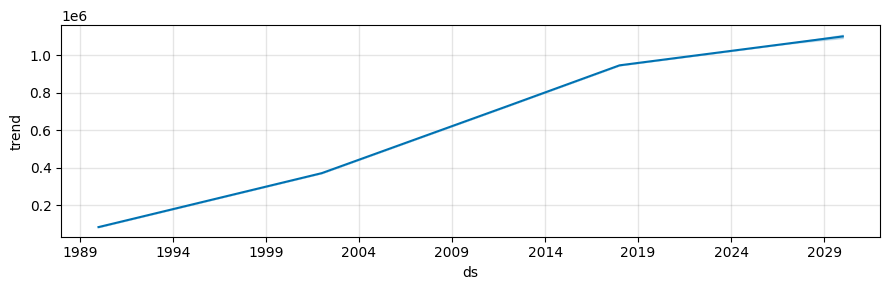


========== MODEL PERFORMANCE ==========

Country : Kuwait
Mean Migration : 588,784
RMSE : 25,433.54
MAE : 16,956.24
RMSE Percentage : 4.32%
MAE Percentage : 2.88%
MAPE : 12.83%
Forecast Accuracy : 87.17%

Forecast saved as 'Kuwait_Migration_Forecast_2027_2030.xlsx'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================
# DISPLAY SETTINGS (NO SCIENTIFIC NOTATION)
# =====================================================

pd.set_option('display.float_format', '{:,.2f}'.format)

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

# =====================================================
# SELECT COUNTRY
# =====================================================

country = "Kuwait"

df = df[df["Country"] == country].copy()

df = df.sort_values("Year")

# =====================================================
# PREPARE DATA
# =====================================================

prophet_df = df[["Year", "Migration"]].copy()

prophet_df.columns = ["ds", "y"]

prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"].astype(str) + "-01-01"
)

# =====================================================
# BUILD PROPHET MODEL
# =====================================================

model = Prophet(

    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.2

)

model.fit(prophet_df)

# =====================================================
# FORECAST TO 2030
# =====================================================

future = model.make_future_dataframe(

    periods=4,
    freq="YS"

)

forecast = model.predict(future)

# =====================================================
# FORECAST TABLE
# =====================================================

forecast_2030 = forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].copy()

forecast_2030["Year"] = forecast_2030["ds"].dt.year

forecast_2030 = forecast_2030[
    forecast_2030["Year"] >= 2027
]

forecast_2030 = forecast_2030[
    ["Year", "yhat", "yhat_lower", "yhat_upper"]
]

forecast_2030.columns = [

    "Year",
    "Predicted_Migration",
    "Lower_Bound",
    "Upper_Bound"

]

# Convert to whole numbers

forecast_2030 = forecast_2030.round(0)

forecast_2030["Predicted_Migration"] = forecast_2030["Predicted_Migration"].astype(int)
forecast_2030["Lower_Bound"] = forecast_2030["Lower_Bound"].astype(int)
forecast_2030["Upper_Bound"] = forecast_2030["Upper_Bound"].astype(int)

# Format with commas

forecast_display = forecast_2030.copy()

forecast_display["Predicted_Migration"] = forecast_display["Predicted_Migration"].map('{:,}'.format)
forecast_display["Lower_Bound"] = forecast_display["Lower_Bound"].map('{:,}'.format)
forecast_display["Upper_Bound"] = forecast_display["Upper_Bound"].map('{:,}'.format)

print("\n========== KUWAIT FORECAST (2027-2030) ==========\n")

print(forecast_display)

# =====================================================
# FORECAST GRAPH
# =====================================================

fig = model.plot(forecast)

plt.title("Kuwait Migration Forecast (2027-2030)")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(True)

plt.show()

# =====================================================
# COMPONENTS
# =====================================================

fig2 = model.plot_components(forecast)

plt.show()

# =====================================================
# MODEL EVALUATION
# =====================================================

prediction = forecast.iloc[:len(prophet_df)]

actual = prophet_df["y"].values

predicted = prediction["yhat"].values

rmse = np.sqrt(mean_squared_error(actual, predicted))

mae = mean_absolute_error(actual, predicted)

mean_migration = actual.mean()

rmse_percent = (rmse / mean_migration) * 100

mae_percent = (mae / mean_migration) * 100

mask = actual != 0

mape = np.mean(

    np.abs(
        (actual[mask] - predicted[mask]) /
        actual[mask]
    )

) * 100

accuracy = 100 - mape

# =====================================================
# RESULTS
# =====================================================

print("\n========== MODEL PERFORMANCE ==========\n")

print(f"Country : {country}")

print(f"Mean Migration : {mean_migration:,.0f}")

print(f"RMSE : {rmse:,.2f}")

print(f"MAE : {mae:,.2f}")

print(f"RMSE Percentage : {rmse_percent:.2f}%")

print(f"MAE Percentage : {mae_percent:.2f}%")

print(f"MAPE : {mape:.2f}%")

print(f"Forecast Accuracy : {accuracy:.2f}%")

# =====================================================
# SAVE FORECAST TO EXCEL
# =====================================================

forecast_2030.to_excel(
    "Kuwait_Migration_Forecast_2027_2030.xlsx",
    index=False
)

print("\nForecast saved as 'Kuwait_Migration_Forecast_2027_2030.xlsx'")